## **Memprediksi Produksi Tanaman Padi Di Wilayah Sumatera Dengan Menggunakan Model Regression**

In [1]:
# Import semua library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import shapiro
%matplotlib inline

In [2]:
# Load dataset
df = pd.read_csv('Data_Tanaman_Padi_Sumatera_version_1.csv')
df.head(10)

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31
5,Aceh,1998,1404580.0,365892.0,1465.0,82.60,26.84
6,Aceh,1999,1478712.0,359817.0,1778.0,82.79,26.14
7,Aceh,2000,1486909.0,336765.0,1974.7,90.60,27.10
8,Aceh,2001,1547499.0,295212.0,1688.7,69.48,28.90
9,Aceh,2002,1314165.0,315131.0,1296.8,68.75,29.20


In [3]:
print(f'Jumlah baris pada data : {df.shape[0]} Jumlah Kolom pada data : {df.shape[1]}')
print("\n")
df.info()

Jumlah baris pada data : 224 Jumlah Kolom pada data : 7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provinsi        224 non-null    object 
 1   Tahun           224 non-null    int64  
 2   Produksi        224 non-null    float64
 3   Luas Panen      224 non-null    float64
 4   Curah hujan     224 non-null    float64
 5   Kelembapan      224 non-null    float64
 6   Suhu rata-rata  224 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.4+ KB


In [4]:
df.isnull().sum()

Provinsi          0
Tahun             0
Produksi          0
Luas Panen        0
Curah hujan       0
Kelembapan        0
Suhu rata-rata    0
dtype: int64

In [5]:
df['Provinsi'].unique()

array(['Aceh', 'Sumatera Utara', 'Sumatera Barat', 'Riau', 'Jambi',
       'Sumatera Selatan', 'Bengkulu', 'Lampung'], dtype=object)

In [6]:
df.describe(include='all')

,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
count,224,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN
top,Aceh,NaN,NaN,NaN,NaN,NaN,NaN
freq,28,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964
std,NaN,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041
min,NaN,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000
25%,NaN,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500
50%,NaN,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000
75%,NaN,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000


## Exploratory Data Analysis (EDA)

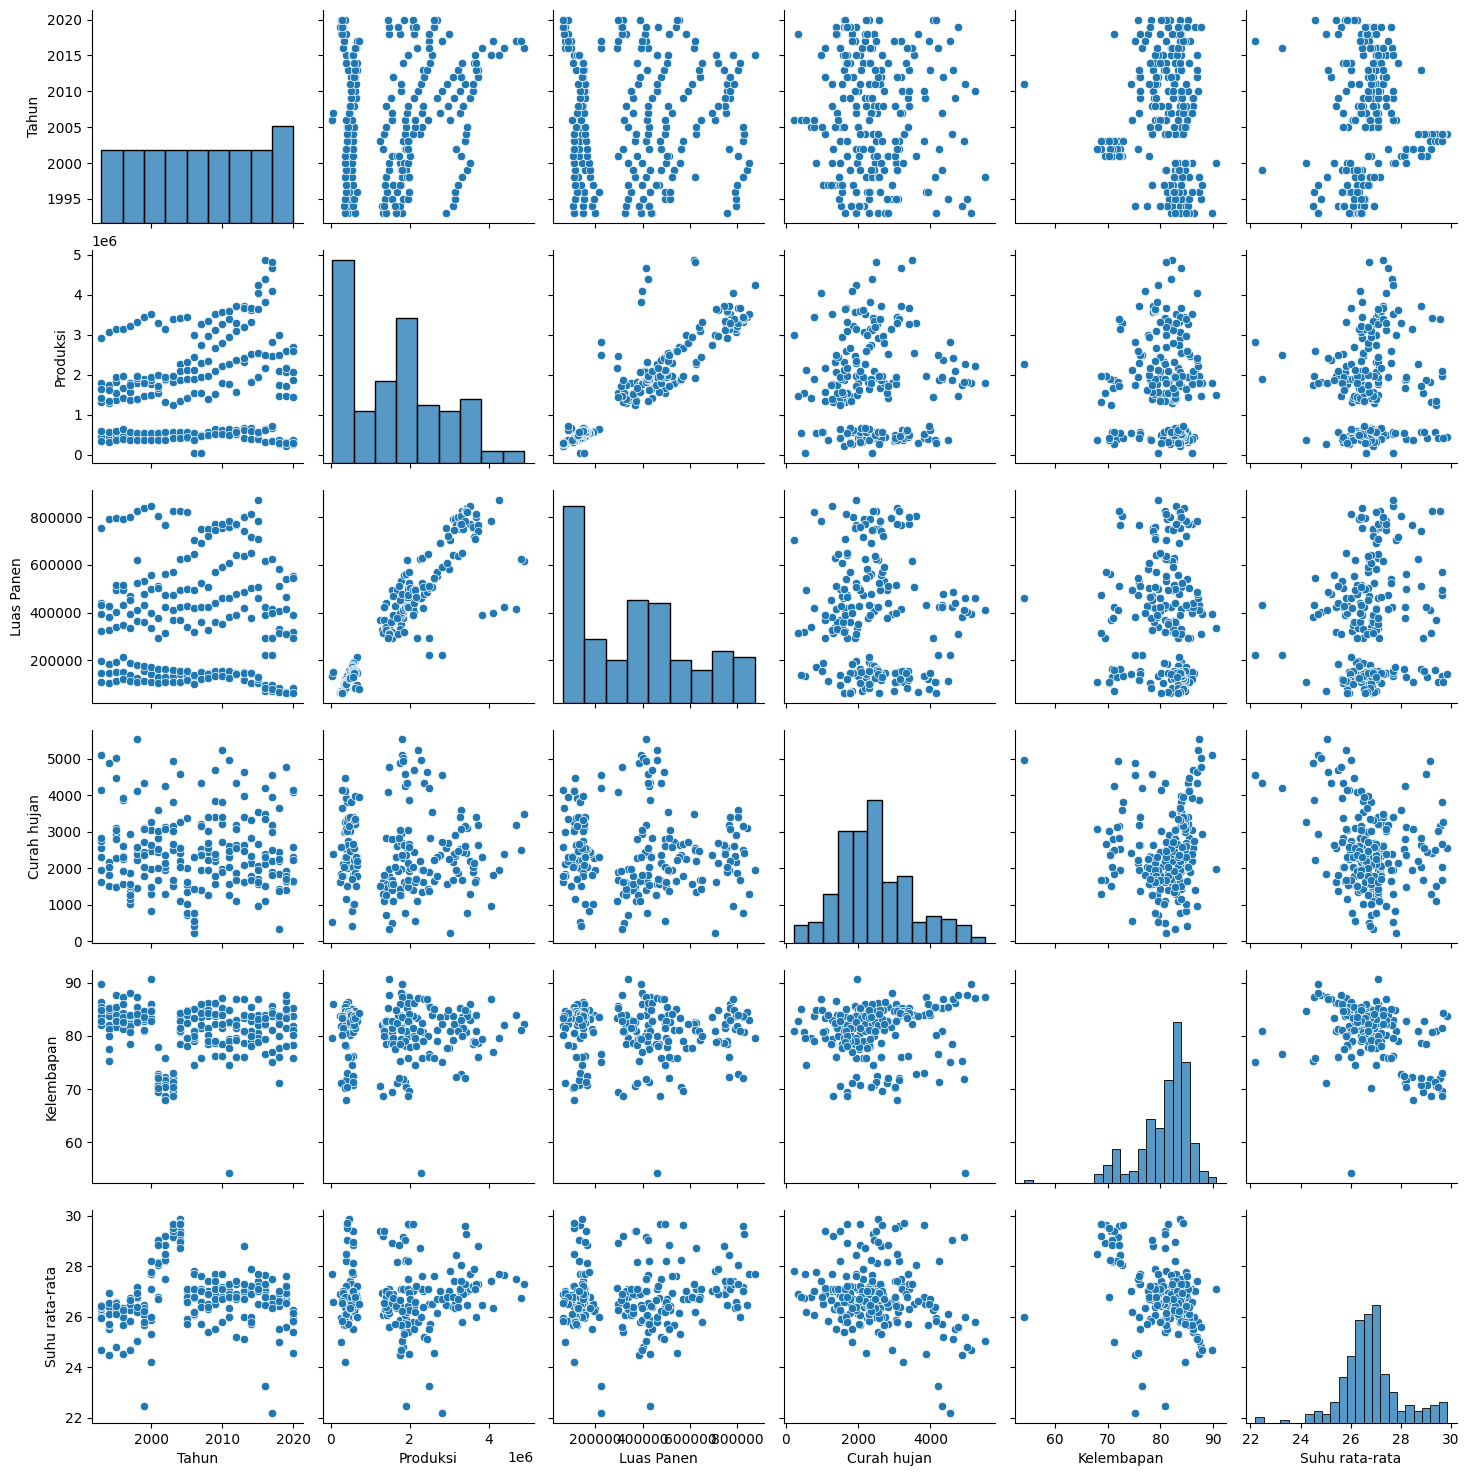

In [7]:
sns.pairplot(df)

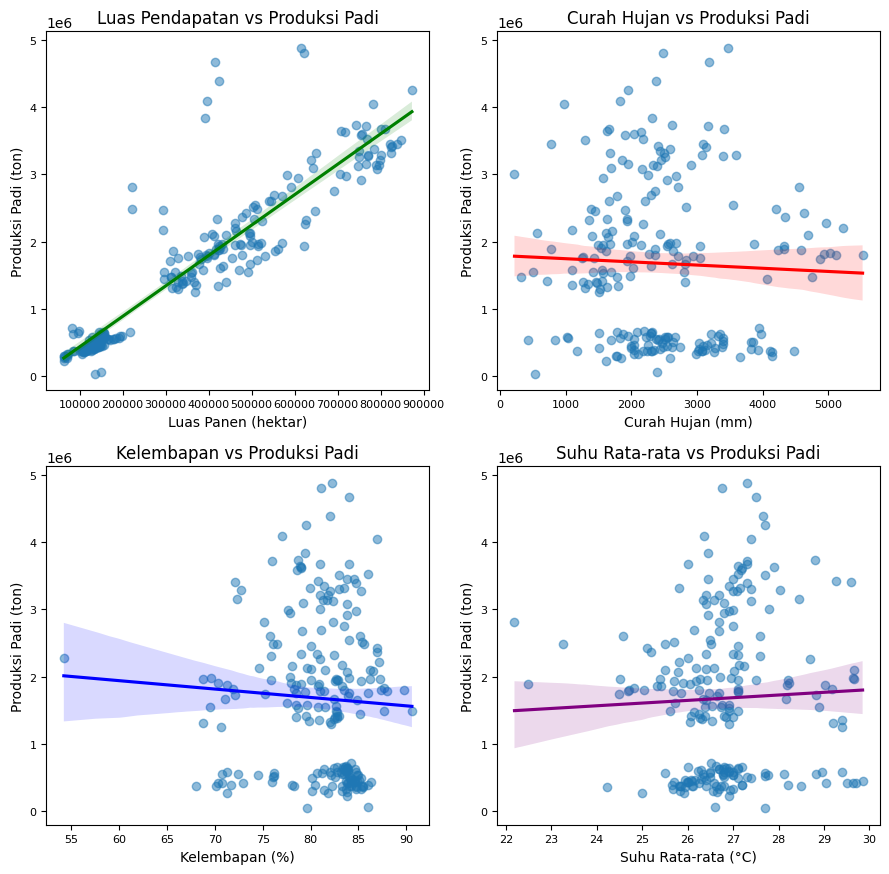

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))

# Hubungan antara luas panen dan produksi padi
sns.regplot(ax=axes[0, 0], x=df['Luas Panen'], y=df['Produksi'], scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[0, 0].set_title('Luas Pendapatan vs Produksi Padi')
axes[0, 0].set_xlabel('Luas Panen (hektar)')
axes[0, 0].set_ylabel('Produksi Padi (ton)')
axes[0, 0].tick_params(labelsize=8)

# Hubungan antara curah hujan dan produksi padi
sns.regplot(ax=axes[0, 1], x='Curah hujan', y='Produksi', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0, 1].set_title('Curah Hujan vs Produksi Padi')
axes[0, 1].set_xlabel('Curah Hujan (mm)')
axes[0, 1].set_ylabel('Produksi Padi (ton)')
axes[0, 1].tick_params(labelsize=8)

# Hubungan antara kelembapan dan produksi padi
sns.regplot(ax=axes[1, 0], x=df['Kelembapan'], y=df['Produksi'], scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
axes[1, 0].set_title('Kelembapan vs Produksi Padi')
axes[1, 0].set_xlabel('Kelembapan (%)')
axes[1, 0].set_ylabel('Produksi Padi (ton)')
axes[1, 0].tick_params(labelsize=8)

# Hubungan antara suhu rata-rata dan produksi padi
sns.regplot(ax=axes[1, 1], x=df['Suhu rata-rata'], y=df['Produksi'], scatter_kws={'alpha':0.5}, line_kws={'color':'purple'})
axes[1, 1].set_title('Suhu Rata-rata vs Produksi Padi')
axes[1, 1].set_xlabel('Suhu Rata-rata (°C)')
axes[1, 1].set_ylabel('Produksi Padi (ton)')
axes[1, 1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribusi Produksi')

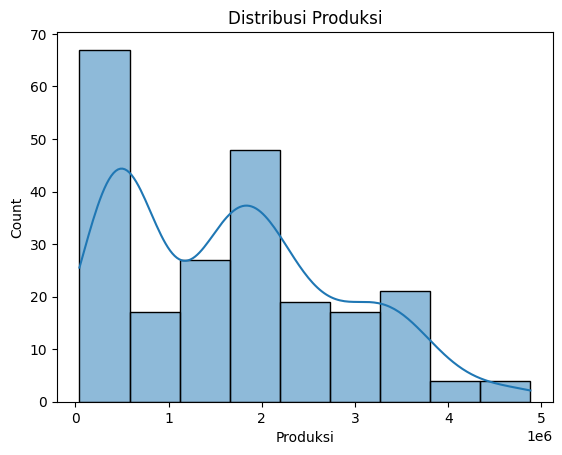

In [9]:
sns.histplot(df['Produksi'], kde=True)
plt.title("Distribusi Produksi")

In [10]:
df.corr(numeric_only=True)

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
Tahun,1.000000,0.182527,-0.045951,-0.047645,-0.033474,0.004923
Produksi,0.182527,1.000000,0.905622,-0.042129,-0.052316,0.041160
Luas Panen,-0.045951,0.905622,1.000000,-0.092975,-0.061121,0.115726
Curah hujan,-0.047645,-0.042129,-0.092975,1.000000,0.056466,-0.228699
Kelembapan,-0.033474,-0.052316,-0.061121,0.056466,1.000000,-0.407799
Suhu rata-rata,0.004923,0.041160,0.115726,-0.228699,-0.407799,1.000000


<Axes: >

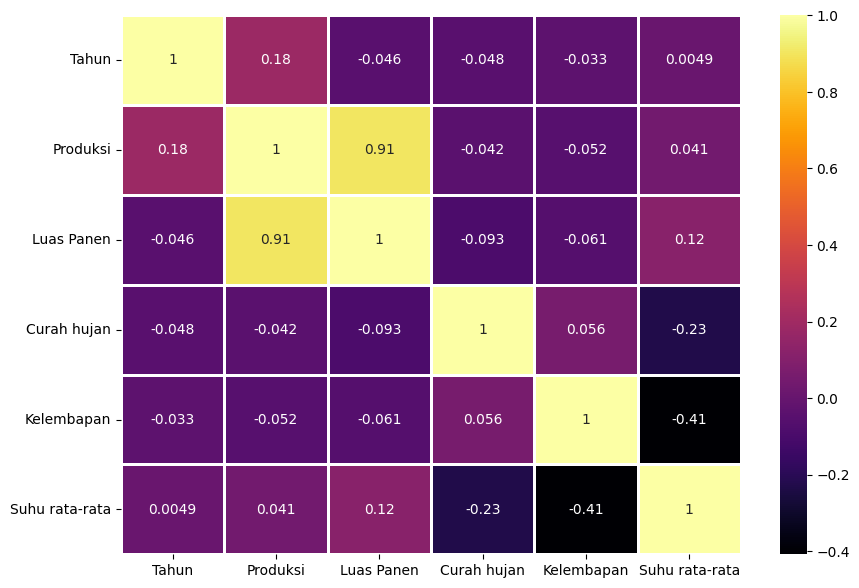

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=2, cmap='inferno')

/tmp/ipykernel_9342/4229613809.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_Pendapatan_by_province.index, y=average_Pendapatan_by_province.values, palette="mako")


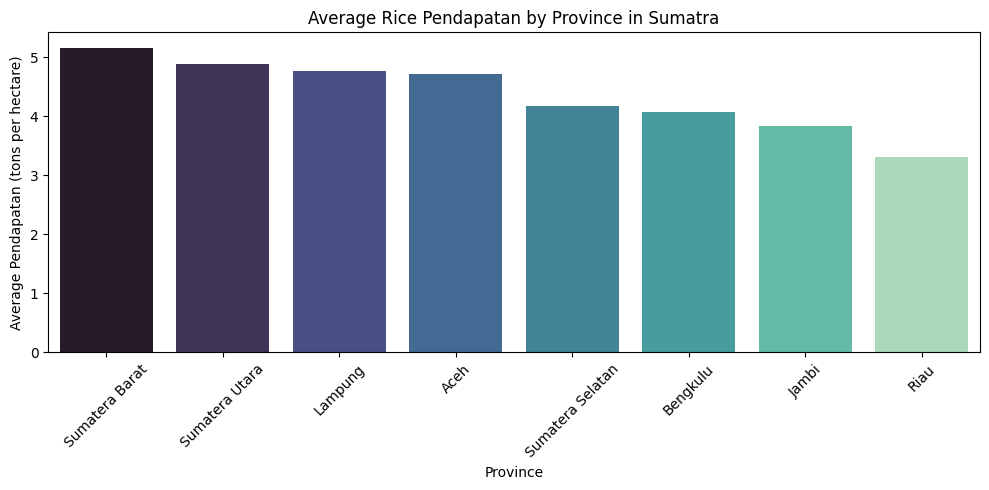

In [12]:
df['Pendapatan'] = df['Produksi'] / df['Luas Panen'] # Count pendapatan

plt.figure(figsize=(10, 5))
average_Pendapatan_by_province = df.groupby('Provinsi')['Pendapatan'].mean().sort_values(ascending=False)
sns.barplot(x=average_Pendapatan_by_province.index, y=average_Pendapatan_by_province.values, palette="mako")
plt.title('Average Rice Pendapatan by Province in Sumatra')
plt.xlabel('Province')
plt.ylabel('Average Pendapatan (tons per hectare)')
plt.xticks(rotation=45)
plt.tight_layout()

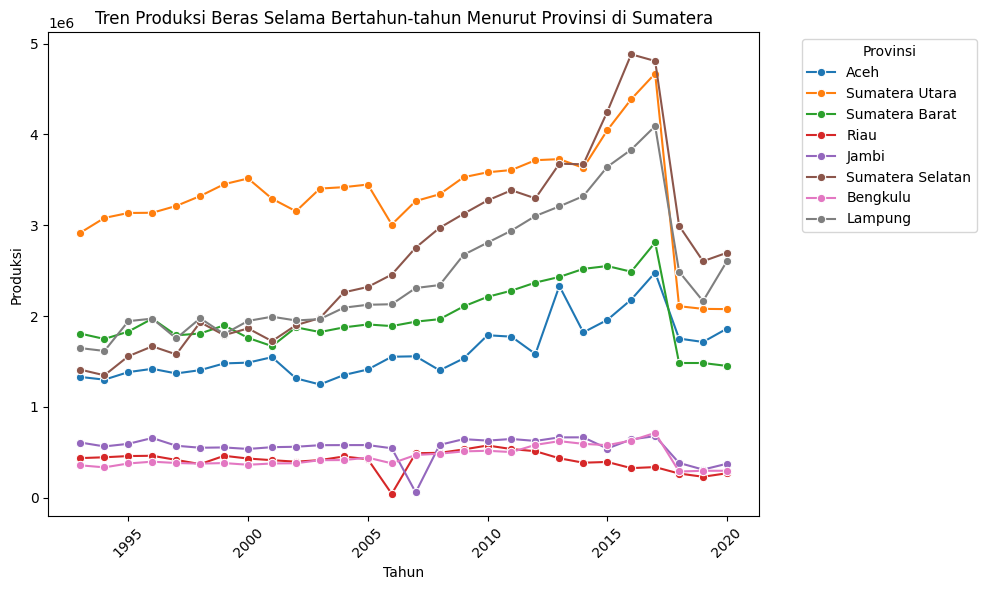

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Tahun', y='Produksi', hue='Provinsi', data=df, marker='o')
plt.title("Tren Produksi Beras Selama Bertahun-tahun Menurut Provinsi di Sumatera")
plt.xlabel("Tahun")
plt.ylabel('Produksi')
plt.legend(title='Provinsi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Encoding

In [14]:
df = pd.get_dummies(df, columns=['Provinsi'], drop_first=True)

In [15]:
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
df.head()

,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Pendapatan,Provinsi_Bengkulu,Provinsi_Jambi,Provinsi_Lampung,Provinsi_Riau,Provinsi_Sumatera Barat,Provinsi_Sumatera Selatan,Provinsi_Sumatera Utara
0,1993,1329536.0,323589.0,1627.0,82.00,26.06,4.108718,0,0,0,0,0,0,0
1,1994,1299699.0,329041.0,1521.0,82.12,26.92,3.949961,0,0,0,0,0,0,0
2,1995,1382905.0,339253.0,1476.0,82.72,26.27,4.076324,0,0,0,0,0,0,0
3,1996,1419128.0,348223.0,1557.0,83.00,26.08,4.075343,0,0,0,0,0,0,0
4,1997,1368074.0,337561.0,1339.0,82.46,26.31,4.052820,0,0,0,0,0,0,0


## Training

In [16]:
X = df.drop(columns=['Produksi'])
y = df['Produksi']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X train shape : {X_train.shape}')
print(f'X test shape : {X_test.shape}')

X train shape : (179, 13)
X test shape : (45, 13)


In [18]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [19]:
print("=== Linear Regression ===")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R² Test : {r2_score(y_test, y_pred_lr):.3f}")
print(f"R² Train : {r2_score(y_train, model_lr.predict(X_train)):.3f}")

=== Linear Regression ===
MAE : 137,491
RMSE : 250,213
R² Test : 0.929
R² Train : 0.971


Text(0.5, 1.0, 'Residuals vs Prediksi')

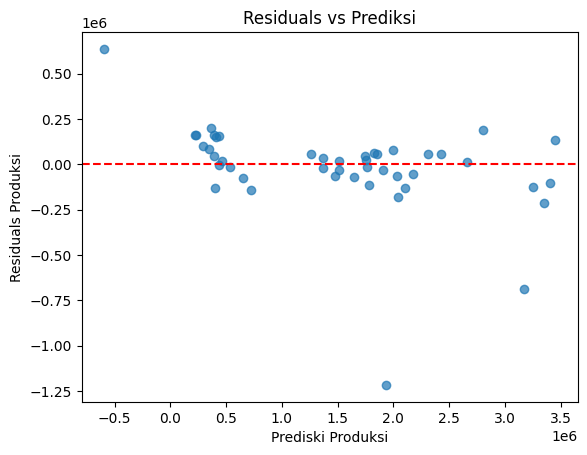

In [20]:
residuals_lr = y_test - y_pred_lr 

plt.scatter(y_pred_lr, residuals_lr, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Prediski Produksi")
plt.ylabel("Residuals Produksi")
plt.title("Residuals vs Prediksi")

Text(0.5, 1.0, 'Aktual vs Prediksi')

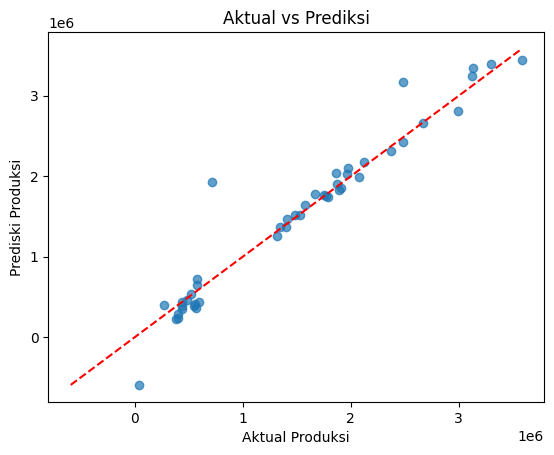

In [21]:
plt.scatter(y_test, y_pred_lr, alpha=0.7)

min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], '--r')
 
plt.xlabel("Aktual Produksi")
plt.ylabel("Prediski Produksi")
plt.title("Aktual vs Prediksi")

In [22]:
stat, p_value = shapiro(residuals_lr)
print('Shapiro-Wilk Test (Uji Normalitas Residuals):')
print(f'  Test Statistic : {stat:.4f}')
print(f'  P-Value        : {p_value:.4f}')
print()
if p_value > 0.05:
    print('Residuals terdistribusi NORMAL (p > 0.05) — asumsi terpenuhi!')
else:
    print('Residuals TIDAK normal (p <= 0.05) — pertimbangkan model lain')

Shapiro-Wilk Test (Uji Normalitas Residuals):
  Test Statistic : 0.7085
  P-Value        : 0.0000

Residuals TIDAK normal (p <= 0.05) — pertimbangkan model lain


## Random Forest Regressor

In [23]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    n_jobs=1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("=== Random Forest Regressor ===")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"R² Test : {r2_score(y_test, y_pred_rf):.3f}")
print(f"R² Train : {r2_score(y_train, model_rf.predict(X_train)):.3f}")



=== Random Forest Regressor ===
MAE : 171,509
RMSE : 244,268
R² Test : 0.933
R² Train : 0.963
